In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
csv_url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/projects/student_completion/data/Course_Completion_Prediction.csv"
student_df = pd.read_csv(csv_url, usecols=lambda col: not col.startswith("Unnamed"))
student_df.head()

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [ ]:
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Student_ID                    100000 non-null  object 
 1   Name                          100000 non-null  object 
 2   Gender                        100000 non-null  object 
 3   Age                           100000 non-null  int64  
 4   Education_Level               100000 non-null  object 
 5   Employment_Status             100000 non-null  object 
 6   City                          100000 non-null  object 
 7   Device_Type                   100000 non-null  object 
 8   Internet_Connection_Quality   100000 non-null  object 
 9   Course_ID                     100000 non-null  object 
 10  Course_Name                   100000 non-null  object 
 11  Category                      100000 non-null  object 
 12  Course_Level                  100000 non-null

In [26]:
student_df.Completed.value_counts()

Completed
Not Completed    50970
Completed        49030
Name: count, dtype: int64

In [29]:
student_df.copy()
student_df["Completed"] = student_df["Completed"].map({
    "Not Completed": 0,
    "Completed": 1,
})

In [30]:
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Student_ID                    100000 non-null  object 
 1   Name                          100000 non-null  object 
 2   Gender                        100000 non-null  object 
 3   Age                           100000 non-null  int64  
 4   Education_Level               100000 non-null  object 
 5   Employment_Status             100000 non-null  object 
 6   City                          100000 non-null  object 
 7   Device_Type                   100000 non-null  object 
 8   Internet_Connection_Quality   100000 non-null  object 
 9   Course_ID                     100000 non-null  object 
 10  Course_Name                   100000 non-null  object 
 11  Category                      100000 non-null  object 
 12  Course_Level                  100000 non-null

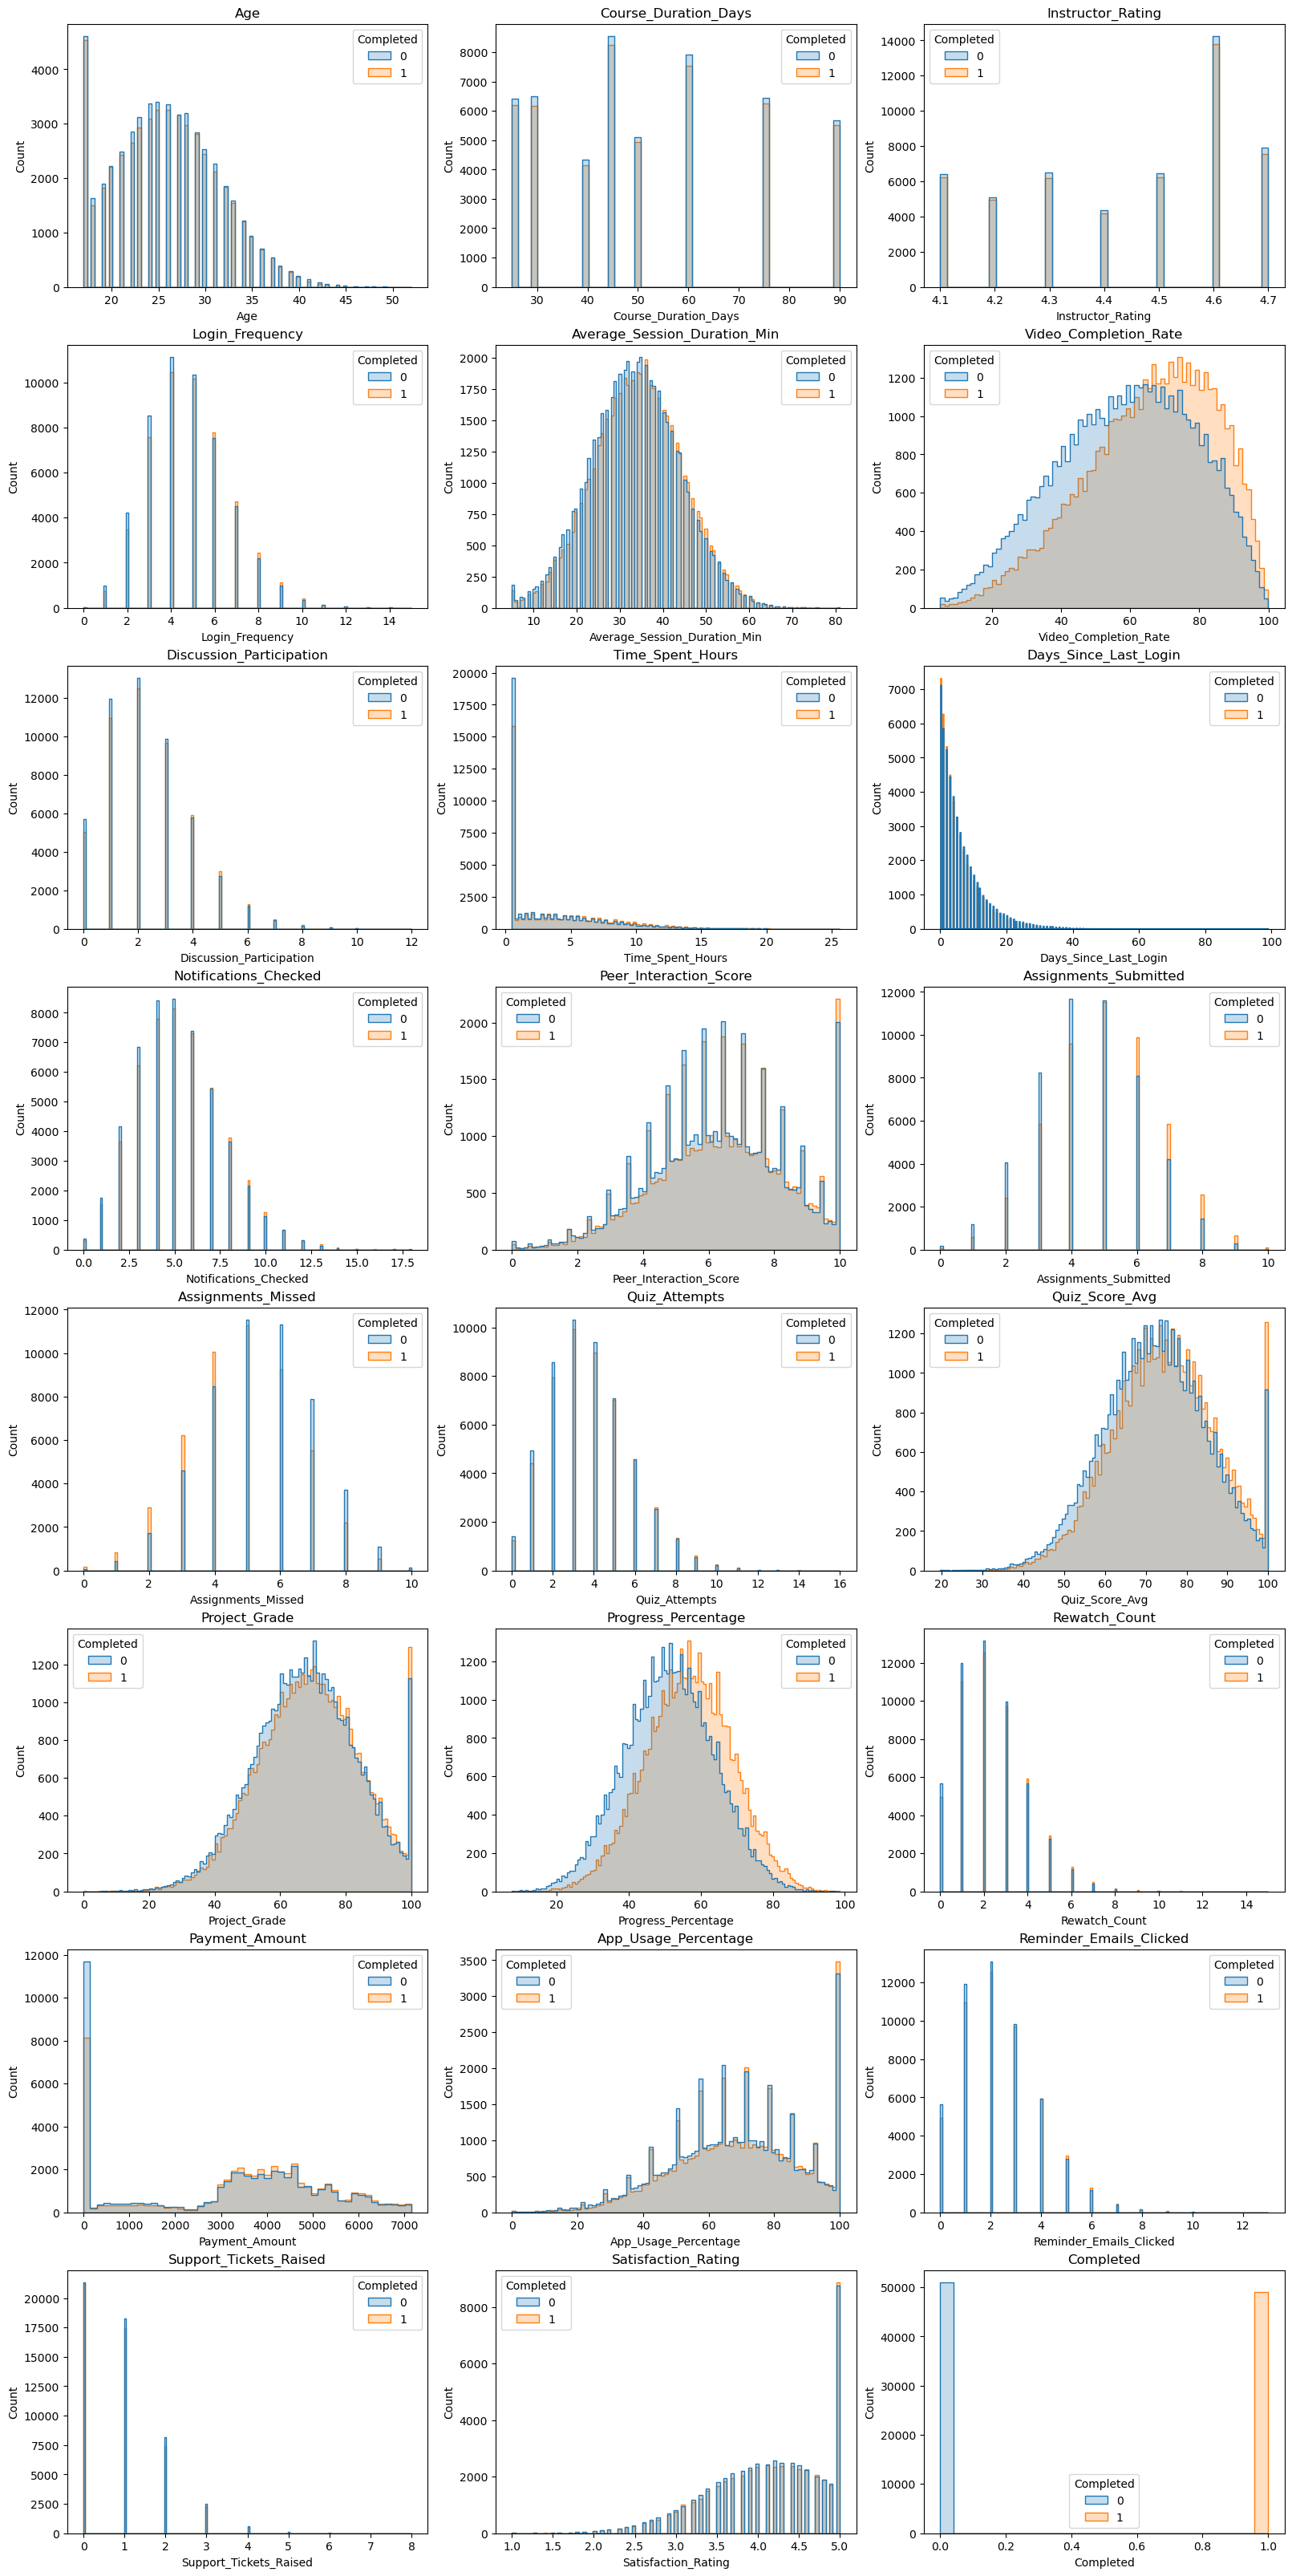

In [39]:
numeric_features = student_df.select_dtypes("number").columns.to_list()
target = "Completed"

# Calculate grid size
n_cols = 3
n_rows = (len(numeric_features) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), layout="constrained")
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(data=student_df, x=col, hue=target, element="step", ax=axes[i])
    axes[i].set_title(col)
plt.show()

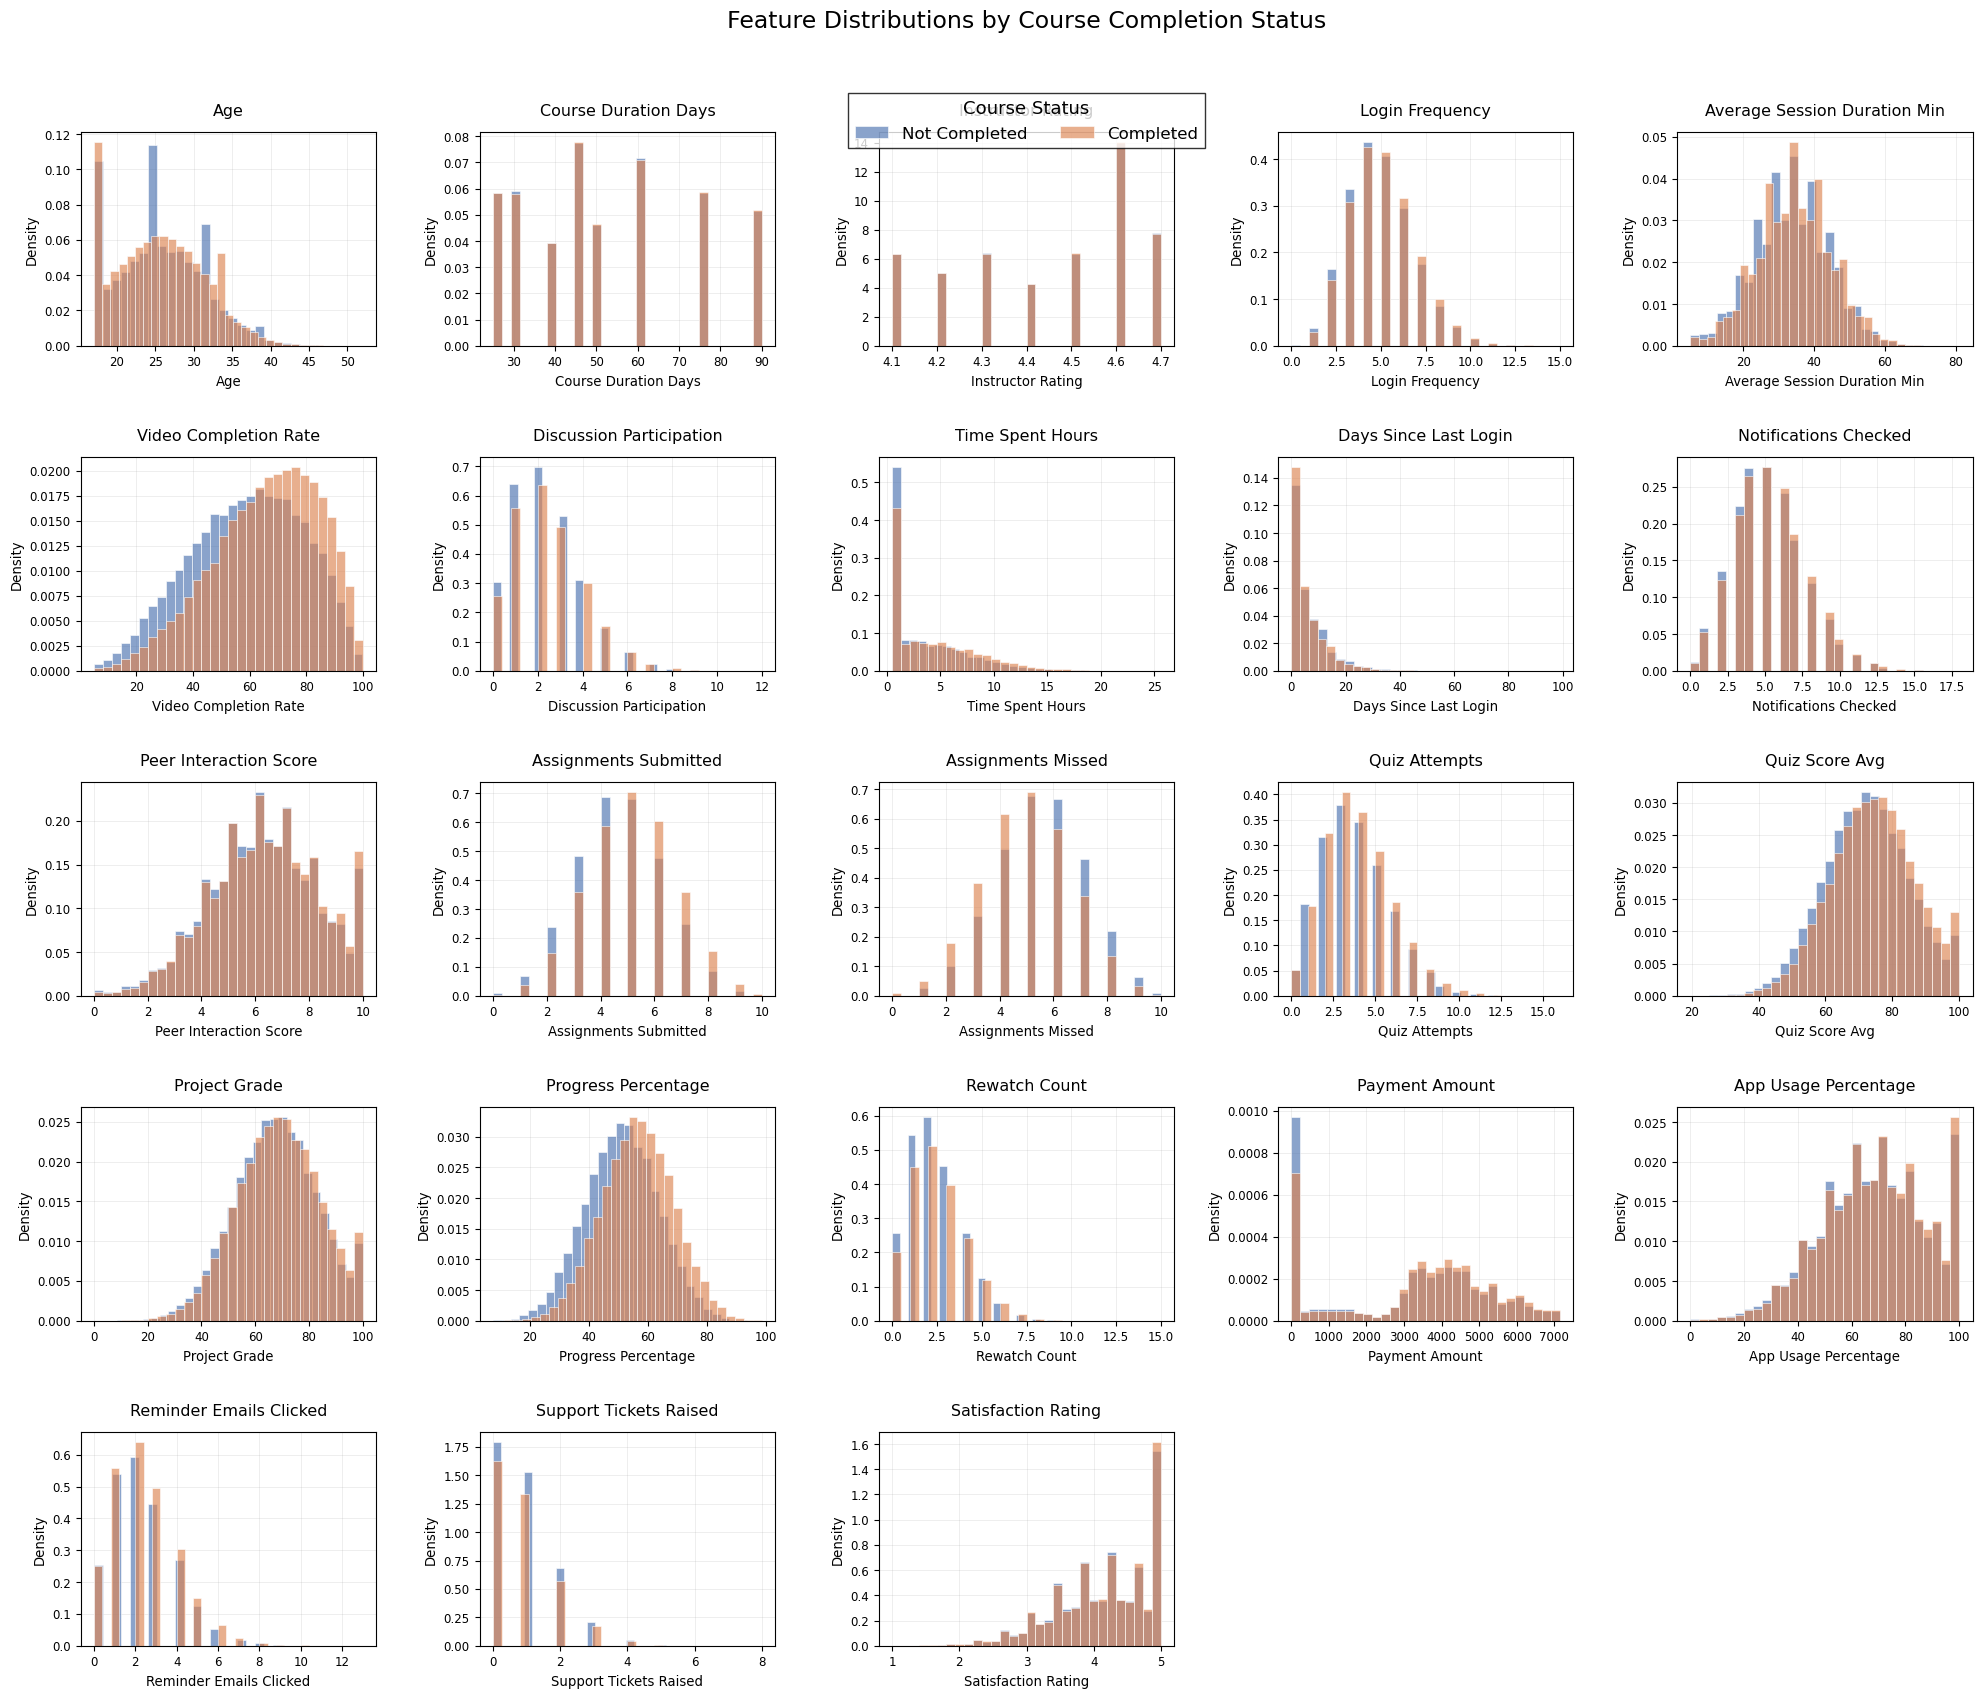

In [ ]:
# Exclude the target if it's numeric (safety)
feature_names = [
    col for col in student_df.select_dtypes("number").columns if col != "Completed"
]
num_features = len(feature_names)

# Layout preferences
n_cols = 5
n_rows = int(np.ceil(num_features / n_cols))

# Size per subplot + extra height for title/legend
width_per_plot = 4.3
height_per_plot = 3.3
fig = plt.figure(
    figsize=(n_cols * width_per_plot, n_rows * height_per_plot + 1.0)
)  # reduced slightly, still ample

# GridSpec with controlled spacing
gs = fig.add_gridspec(n_rows, n_cols, wspace=0.35, hspace=0.52)

axes = gs.subplots()
axes_flat = axes.flatten()

# Colors (colorblind-friendly, matches your screenshot)
color_not = "#4C72B0"  # muted blue
color_yes = "#DD8452"  # coral/orange

for idx, feature in enumerate(feature_names):
    ax = axes_flat[idx]

    for status, color, label in [
        ("Not Completed", color_not, "Not Completed"),
        ("Completed", color_yes, "Completed"),
    ]:
        data = student_df[student_df["Completed"] == status][feature].dropna()
        if len(data) > 0:
            ax.hist(
                data,
                bins=30,
                density=True,
                alpha=0.65,
                color=color,
                edgecolor="white",
                linewidth=0.6,
                label=label,
            )

    ax.set_title(feature.replace("_", " "), fontsize=11.5, pad=12)
    ax.set_xlabel(feature.replace("_", " "), fontsize=9.5)
    ax.set_ylabel("Density", fontsize=9.5)
    ax.tick_params(axis="both", labelsize=8.5)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

# Hide unused subplots
for j in range(num_features, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Legend (perfectly centered on top)
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.952),
    ncol=2,
    fontsize=12,
    title="Course Status",
    title_fontsize=13,
    frameon=True,
    fancybox=False,
    edgecolor="black",
)

# Main title
fig.suptitle(
    "Feature Distributions by Course Completion Status",
    fontsize=17,
    y=0.995,
)

# === Critical fix: manual margins instead of tight_layout ===
# This completely eliminates the UserWarning while giving perfect control
fig.subplots_adjust(
    top=0.925,  # leaves generous space at the top
    bottom=0.06,
    left=0.06,
    right=0.94,
)

# No plt.tight_layout() → no warning, no layout issues
plt.show()
